## 데이터 분석 전체 흐름

| 단계 | 주요 내용 |
|---|---|
| **1. 데이터 수집** | CSV, Excel, DB, API, 크롤링 |
| **2. 전처리** | 구조진단 → 정제(결측치·이상치) → 문자열·시계열 → 정리·변환 → 재구조화 → 스케일링 → 파생변수 → 그룹기반 → 범주형 인코딩 |
| **3. EDA** | 기초통계량 → 단변량 → 이변량 → 다변량 → 시계열 패턴 → 상관관계 |
| **EDA 목적** | 데이터 분포 관찰 · 구조 이해 · 시각화 |
| **4. 추론통계** | 가설검정 → p-value 검증 → 회귀기반 추론(예측·분류) |
| **5. 결과 해석** | 분석 결과 해석 및 인사이트 도출 |

In [1]:
# 탐색적 분석 EDA
# 확증적 데이터 분석 (CDA) : 추론 통계 - 수집한 데이터를 이용하여 추론 예측하는 통계 기법으로 신뢰구간 추정, 유의성 검정 기법 등을 이용
# 탐색적 데이터 분석 (EDA) : 기술 통계 - 수집한 데이터를 요약, 묘사, 설명하는 통계 기법으로 데이터의 대푯값, 분포등을 이용

# EDA(탐색적 데이터 분석)는 데이터를 다양한 통계·시각화 방법으로 탐색하여 분포, 구조, 패턴, 변수간 관계를 이해하는 과정

# 타이타닉 분석

# 분석 목적
# 타이타닉 생존 여부에 영향을 미친 주요 요인에 대한 체계적 분석

In [2]:
# 1. 데이터 수집
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/titanic/train.csv')

# 엑셀로 저장
df_train.to_excel("titanic.xlsx")
# df_train

Mounted at /content/drive


In [3]:
# 2. 전처리 
# 2-1) 구조 진단
df_train.info()  # SibSP - 같이 탑승한 형제,배우자 / Parch - 함께 탑승한 부모,자식 / Fare - 요금 / cabin - 선실 번호 / Embarked - 승선한 항구
# 분석 = 인사이트
# 컬럼명을 한글로 분석완료 하였음
# 3개의 컬럼에서 결측치가 보임 , 총 12개의 컬럼에서 891행의 데이터가 있음 / 추가적으로 나이는 결측치 때문에 float임

df_train.head(100) # 너무 범주가 많은 이름은 필요가 없지만 Mr,Mrs,Miss는 중요한 데이터임
# 분석
# SibSp	Parch => 해당 데이터는 좀 더 분석이 필요

df_train.shape 
# 분석
#(891, 12) 12개의 컬럼 891명의 개인 정보가 담겨져 있음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

In [4]:
!pip install missingno

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


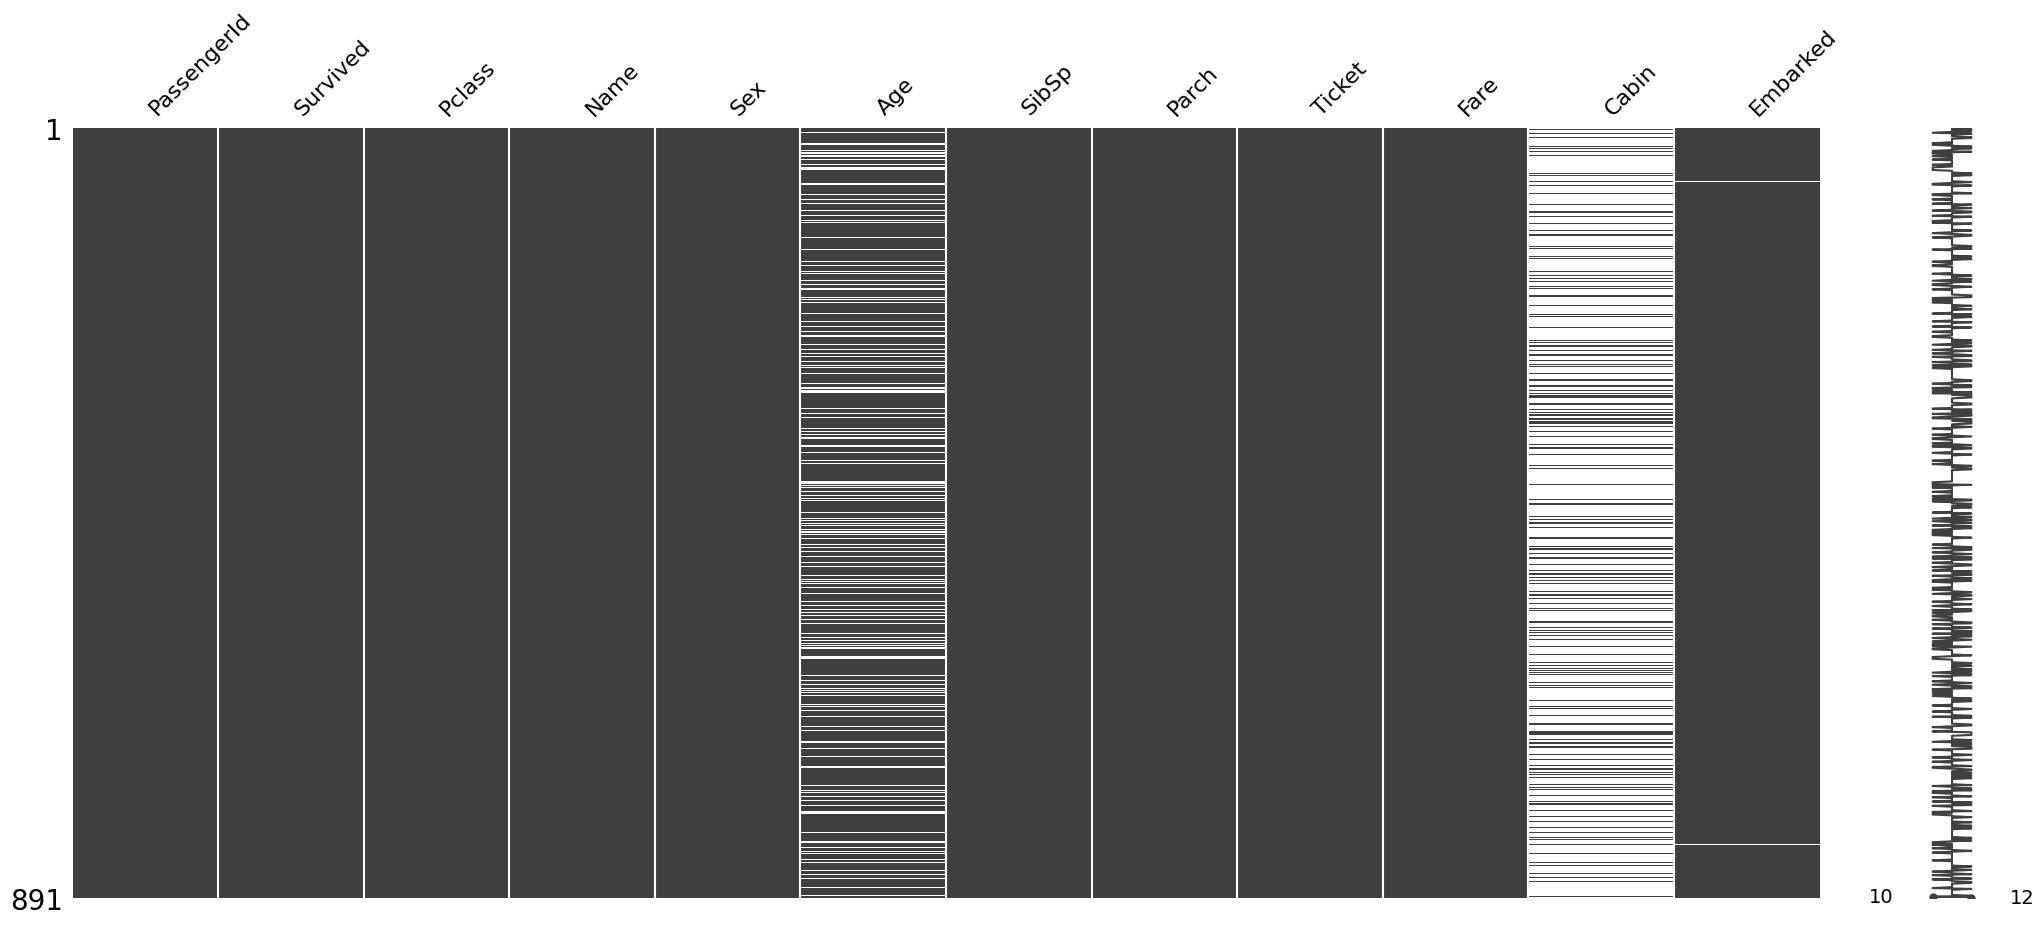

In [5]:
# 2-2) 정제 (결측치, 이상치)

import missingno as msno

df_train.isnull().sum()
msno.matrix(df_train) # 결측치를 시각화로 볼 수 있음

missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
print(missing_pct)

# 1) 순수 데이터 분석만 할 시에는 데이터 정제 및 결측치, 이상치 처리할 필요 없음

# Age 결측치 처리 (1. 평균, 2. 중앙 값, 3.최다 빈도 값)
# 20%면 버리기 아까움
# 판단 => 채우는 방향으로
# Age 연속형 데이터
# 숫자는 => 평균, 중앙값, 최빈값, 최대최소, 예측값으로도 결측값을 채울 수 있음
df_train["Age"].skew() # 왜도 체크 값(0.38)
# 왜도 체크 => 분포가 살짝 치우침
# 예시 (0.38)
# 약간 우측 왜도 => 왜도가 있다는 말은 10, 20, 30, 40, 300 왼쪽으로 끌리는 데이터가 있음
# 평균보다 중앙값 안정

# 왜도 : 왜도는 분포의 비대칭 정도를 측정
# | 왜도 값       | 해석      |
# | ---------- | ------- |
# | -0.5 ~ 0.5 | 거의 대칭   |
# | ±0.5 ~ ±1  | 약간 치우침  |
# | ±1 이상      | 강하게 치우침 |

df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Cabin => 77%
# 결측률이 너무 큼
# 채워도 의미가 없음
# 해당행 제거시 더 큰 위험 => 데이터가 망가짐
# 제거 고려

df_train.drop(columns=["cabin"],errors="ignore",inplace=True)

# Embarked 처리
# 2 / 891 = 결측률 0.2%
# 범주형 데이터
# 최빈값으로 대체

df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

# 전처리 판단기준
#1.결측률 체크
#2.컬럼 타입 체크
#3.데이타 분포
#4.채우면 왜곡 되는가?
#5.제거하면 손실이 큰가?

# 분석, 인사이트 발견
# Age
# → 숫자형 + 20%
# → 중앙값

# Cabin
# → 77%
# → 컬럼 제거

# Embarked
# → 범주형 + 0.2%
# → 최빈값

In [6]:
# 2-3) 문자열 및 시계열 처리

# 예제)
# 1. 이르이 생존률과 차이 및 관계가 있을까?
# 2. 예측에 도움이 되는 정보는 아님
# 3. 범주행이 아니어서 그룹별로 취할 수 없는 정보가 없음

# | Name                       | Title |
# | -------------------------- | ----- |
# | Braund, Mr. Owen Harris    | Mr    |
# | Cumings, Mrs. John Bradley | Mrs   |
# | Heikkinen, Miss. Laina     | Miss  |

# Braund, Mr. Owen Harris
#          ↑
# 추출 결과
# Mr

df_train["Title"] = df_train["Name"].str.extract(" ([A-Za-z]+)\.")

# | Title  | 의미     |
# | ------ | -------  |
# | Mr     | 성인 남성 |
# | Mrs    | 기혼 여성 |
# | Miss   | 미혼 여성 |
# | Master | 어린 남자 |

# Name 그대로 쓰지 않은이유
# 1.모든 이름이 유일함
# 2.데이터 종류 너무 많아짐
# 3.일반화가 어려워짐

df_train

<>:19: SyntaxWarning: invalid escape sequence '\.'
<>:19: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_25496/3876189129.py:19: SyntaxWarning: invalid escape sequence '\.'
  df_train["Title"] = df_train["Name"].str.extract(" ([A-Za-z]+)\.")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [7]:
# 2-4) 정리 및 변환
# 불필요한 컬럼 제거
# 단순한 컬럼수 줄이기는 아님
# 예측및 분석에 도움이 되는 정보인지 체크. 예) 중복인가, 식별자인가? 를 판단해서 제거

# PassengerId
# 승객번호 1번이라 생존했나?
# 승객번호 10번이라 사망했나?
# 번호와 생존은 상관없음
# 실무 에서는 아래를 제거

# 고유번호
# Primary Key
# ID
# UUID => 범용 고유 식별자 ( 예) 네트워크 카드의 맥주소)

# Name 컬럼
# 예시
# Braund, Mr. Owen Harris
# Cumings, Mrs. John Bradley

# 문제:
# 이름 종류가 너무 많음.

# 891명인데
# Name 고유값 ≈ 891개
# 거의 전부 다름.

# Braund → ?
# Owen → ?

# 그래서 # Mr # Mrs # Miss # Master 추출후 제거

# Ticket
# 예시
# A/5 21171
# PC 17599
# STON/O2 3101282

# 생존률과는 연관짓기가 힘듬

df_train["Ticket"].nunique()

# 681
# 891명 중
# 681개 종류
# 너무 많음.

# 분석 및 인사이트
# 컬럼               제거 이유
# PassengerId      단순 식별자
# Name              고유값 과다
# Ticket          종류 과다 + 의미 약함

df_train.drop(['PassengerId','Name','Ticket'],axis=1, inplace=True)
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S,Rev
887,1,1,female,19.0,0,0,30.0000,B42,S,Miss
888,0,3,female,28.0,1,2,23.4500,NaN,S,Miss
889,1,1,male,26.0,0,0,30.0000,C148,C,Mr


In [8]:
# 피처 엔지니어링

# 피처 엔지니어링(Feature Engineering) 은 데이터 분석/머신러닝에서 가장 중요한 단계 중 하나임
# 한 줄 정의부터:
# 기존 데이터를 더 의미 있는 변수(Feature)로 변환하거나 새로 만드는 작업

# 원본 데이터
# ↓
# 모델이 이해하기 쉬운 정보로 가공

# 피처엔지니어링 이해하기
 
# | 종류     | 예시          |
# | ------- | --------------|
# | 결합     | 키+몸무게→BMI  |
# | 분할     | 날짜→연·월·요일 |
# | 구간화    | 나이→연령대    |
# | 문자 추출 | 이름→호칭      |
# | 집계     | 구매금액→평균   |
# | 변환     | 로그 변환      |

# 전처리
# → 데이터를 깨끗하게 만드는 작업

# 피처 엔지니어링
# → 데이터를 똑똑하게 만드는 작업

df_train

# FamilySize 생성
# 원본
# sister + brother + spouse
# Parent + Child
# SibSp Parch
# 1       0
# 2       1
# 본인을 제외하고 SibSp,Parch에 맞는 사람 수마다 1씩 증가

# 2-5) 재구조화
# FamilySize 생성
# 탑승 가족수, 재구조화
df_train["FamilySize"] = df_train["SibSp"] + df_train["Parch"] + 1 # +1은 자기 자신을 추가하는 것

df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr,2
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs,2
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss,1
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs,2
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S,Rev,1
887,1,1,female,19.0,0,0,30.0000,B42,S,Miss,1
888,0,3,female,28.0,1,2,23.4500,NaN,S,Miss,4
889,1,1,male,26.0,0,0,30.0000,C148,C,Mr,1


In [9]:
# 2-6) 스케일링
# 스케일링이란?
# 한 줄 정의 : 서로 다른 크기의 숫자를 비슷한 기준으로 맞추는 것
# 머신러닝 딥러닝 에서 주로 수행
# 데이터 분석시에서 스케일링이 필요 없을수도 있음

# | Age |  Fare |
# | --- | ----- |
# |  22 |  7.25 |
# |  38 | 71.28 |
# |  35 | 53.10 |

# 문제:

# Age   → 0~80
# Fare  → 0~500

# 크기 차이가 큼.
# | 모델         | 스케일링 |
# | ----------  | ------- |
# | 로지스틱 회귀 | 추천     |
# | KNN         | 필수     |
# | SVM         | 필수     |
# | 신경망       | 추천     |
# | 트리         | 불필요   |
# | 랜덤포레스트  | 불필요   |

In [10]:
# 2-7) 정보 조합 ,파생 변수
# 피어 엔지니어링 (Feature Engineering) 에서 아주 많이 쓰이는 구간화 (Binning)
# 연속형 변수를 범주형 변수로 변환

df_train["AgeGroup"] = pd.cut(df_train["Age"],bins=[0,18,40,60,100]) # => cut은 bins에 있는 구간으로 짜르는 것 (18,40)은 18살~40살 사이라는 의미
df_train

# df_train["AgeGroup"] = pd.cut(
#     df_train["Age"],
#     bins=[0,18,40,60,100],
#     labels = [
#         "Child",
#         "Adult",
#         "Middle",
#         "Old"
#     ]
# )
# df_train

df_train.groupby("AgeGroup")["Survived"].mean()
# 어린이 생존률 높음
# 고령층 생존률 낮음

# 인사이트
# 어린이 우선 구조 했을 가능성이 큼

/tmp/ipykernel_25496/2206543077.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
"(0, 18]",0.503597
"(18, 40]",0.360465
"(40, 60]",0.390625
"(60, 100]",0.227273


In [11]:
# 1) 기초통계량 확인

df_train.describe()
df_train.describe().T

# 분석
# 1. Survived
# 평균 : 0.383
# 전체 승객중 약 38%가 생존, 약 62%가 사망

# 2.Pclass 객실 등급
# 평균 : 2.31
# 중앙값 : 3

# 객실: 
# 1 -> 상류층
# 2 -> 중산층
# 3 -> 일반석

# 해석:

# 평균이 : 2.3
# 중앙값이 : 3
# 3등석 승객 많음.
# 즉
# 데이터가 하위 객실에 치우침
#=================================================
# Age = 나이
# 평균 : 29.36
# 표준편차 : 13.0

# 최소 : 0.42
# Q1 : 22
# 중앙값 : 28
# Q3 : 35
# 최대 : 80

# 평균 승객 나이 = 약 29세
# 중앙값 절반은 28세 이하
# Q1  25% 승객 22세 이하
# Q3  75% 승객 35세 이하
# 최대 80세 노인 존재
# 평균 29.36, 중앙값 28 => 차이 작음
# 큰 왜도 없음
# 약간 우측으로 치우침

# SibSp (형제, 자매, 배우자)
# 평균 : 0.52
# 최대 : 8

# 대부분 혼자 또는 1명 동반
# 대가족 8명 탑승 존재
# 중앙값 0 => 절반 이상이 혼자 탑승

# PArch (부모, 자녀 수)
# 평균 : 0.38
# 중앙값 : 0 
# 최대 : 6

# 대부분 부모, 자녀 없이 탑승
# 일부 가족 승객 있음 (75%까지 0.0인걸로 보아 진짜 일부임)

# Fare (탑승 요금)
# 평균 : 32.2
# 중앙값 : 14.5
# 최대 : 512 => 차이가 많이 큼
# 오른쪽 꼬리 => 고가의 티켓이 존재
# Q1 = 7.9, Q3 = 31
# 50%의 승객이 7.9 ~ 31 그런데 최대값이 512  => 엄청 비싼 표가 있으며 평균의 왜곡 가능성이 높음

# 기초 통계량 분석 및 인사이트
# 1. 생존률 약 38%
# 2. 평균 나이 29세
# 3. 절반 이상 가족 없이 탑승
# 4. 운임 비용은 우측 편향이 있음
# 5. Age는 큰 이상치는 없으며, 중앙값으로 대체가 적절

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
FamilySize,891.0,1.904602,1.613459,1.00,1.0000,1.0000,2.0,11.0000


In [12]:
# 단변량 => 이변량 => 다변량

# 2) 단변량 분석
# 컬럼 하나만 보고 분포, 특징, 이상치를 이해하는 분석

# 단변량 분석시 
# 목적에 부합하고 도메인 지직이 있으면, 중요하다고 생각되는 컬럼 분석 실시

# 1. 생존 (Survived)
# 2. 나이 (Age)
# 3. 객실 등급 (Pclass)
# 4. 운임 비용 (Fare)


In [ ]:
# 단변량 2-1) Survived (생존 여부) 단변량 분석

count = (
    df_train["Survived"]
    .value_counts()
)

print("빈도수")
print(count)

print()


# 비율
ratio = (df_train["Survived"].value_counts(normalize = True) * 100)

print("비율(%)")
print(
    ratio.round(2)
)


# 시각화


ax = sns.countplot(
    x="Survived",
    data=df_train
)


# 막대 위 수치 출력
for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f"{height}",
        (
            p.get_x()
            +
            p.get_width()/2,
            height
        ),
        ha="center",
        va="bottom"
    )


plt.title(
    "Survived Distribution"
)



# 인사이트 도출
# 전체 승객의 약 62%가 사망
# 생존률은 약 38%
# 데이터가 사망 쪽으로 약간 치우쳐 있음

| X       | Y       | 목적          | 추천 그래프 | Pandas / Seaborn |
| ------- | ------- | ---------     | ------    | ---------------- |
| 범주형   | 수치형   | 그룹 비교      | 막대그래프  | barplot()      |
| 범주형   | 수치형   | 분포 비교      | 박스플롯    | boxplot()      |
| 범주형   | 수치형   | 분포 + 밀도    | 바이올린플롯 | violinplot()   |
| 범주형   | 수치형   | 평균 + 신뢰구간 | 포인트플롯  | pointplot()    |
| 범주형   | 범주형   | 개수 비교      | 카운트플롯  | countplot()    |
| 범주형   | 범주형   | 비율 비교      | 누적막대    | crosstab()     |
| 수치형   | 수치형   | 관계 분석      | 산점도      | scatterplot()  |
| 수치형   | 수치형   | 상관관계       | 회귀플롯    | regplot()      |
| 수치형   | 수치형   | 분포           | 히스토그램  | histplot()     |
| 수치형   | 수치형   | 분포 밀도      | KDE        | kdeplot()      |
| 시간     | 수치형   | 변화 추세      | 라인플롯    | lineplot()     |
| 수치형 여러개 | 수치형 여러개 | 상관 비교     | 히트맵    | heatmap()      |

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


<Axes: xlabel='Age', ylabel='Count'>

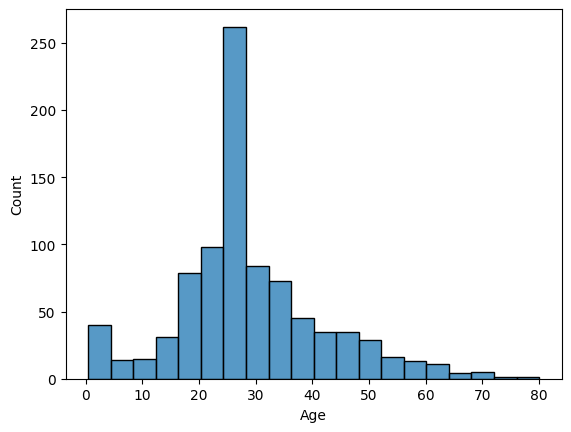

In [ ]:
# 단변량 2-2) 나이 (Age)

print(
df_train["Age"]
.describe()
)

sns.histplot(
df_train["Age"],
bins=20
)

# 20 ~ 30세 가장 많음
# 어린 아이 존재
# 노인 존재
# 약한 우측 왜도

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    55.11
1    24.24
2    20.65
Name: proportion, dtype: float64


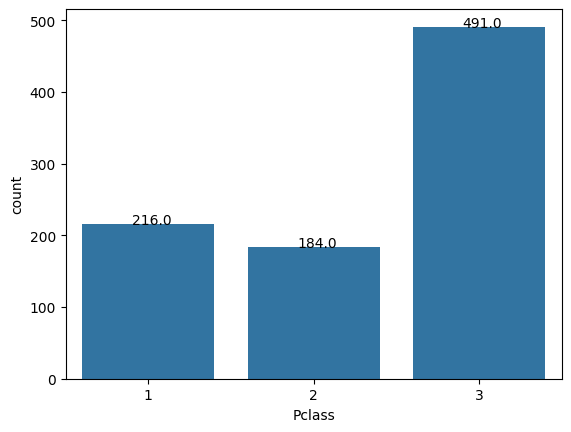

In [ ]:
# 단변량 2-3) Pclass (객실 등급)

count=df_train["Pclass"].value_counts()

ratio=(
df_train["Pclass"]
.value_counts(
normalize=True
)
*100
)

print(count)
print(ratio.round(2))

ax=sns.countplot(
x="Pclass",
data=df_train
)

for p in ax.patches:

 ax.annotate(
  p.get_height(),

 (
 p.get_x()+0.3,
 p.get_height()
 )
 )

 # 분석
 # 1. 3등석 승객 비율이 가장 높음 (55.11%)
 # 2. 하위 객실 승객이 많음
 # 3. 1등급 실이 2등급 승객보다 더 많음

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


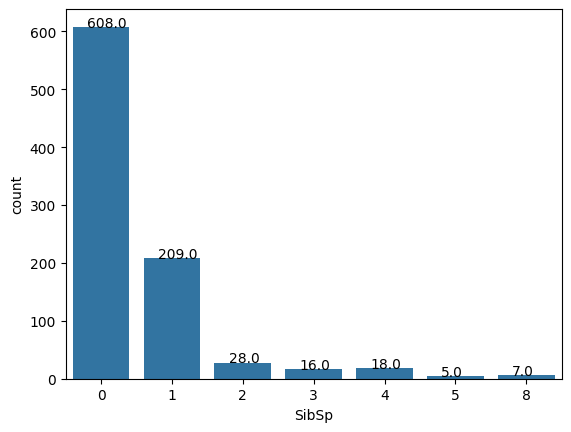

In [ ]:
# 단변량 2-4) SibSp (형제, 배우자 수)

print(
df_train["SibSp"]
.value_counts()
)

ax=sns.countplot(
x="SibSp",
data=df_train
)

for p in ax.patches:

 ax.annotate(
 p.get_height(),
 (
 p.get_x()+0.2,
 p.get_height()
 )
 )

# 분석
# 대부분 혼자 탑승
# 일부는 가족 함께 탑승

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: proportion, dtype: float64


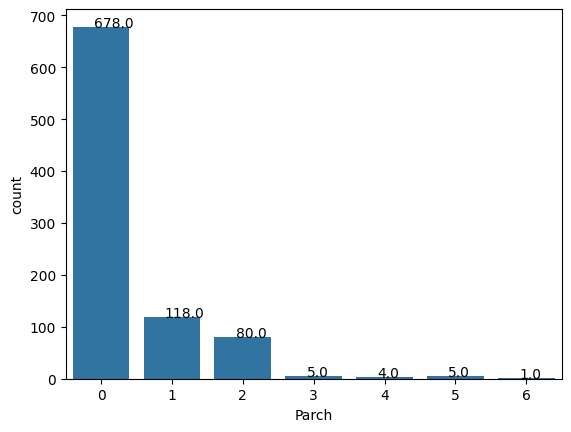

In [ ]:
# 단변량 2-5) Parch (부모·자녀 수)

count = df_train["Parch"].value_counts()
print(count)

ratio = df_train["Parch"].value_counts(normalize=True) * 100 # normalize 잡고 100을 곱하면 백분율로 나타남
print(ratio)

ax=sns.countplot(
x="Parch",
data=df_train
)

for p in ax.patches:

 ax.annotate(
  p.get_height(),
 (
 p.get_x()+0.3,
 p.get_height()
 )
 )
 # 분석
 # 대부분 혼자 탑승 76%
 # 부모 또는 자식과 함께 탄 케이스는 21% 정도임

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


<Axes: xlabel='Fare', ylabel='Count'>

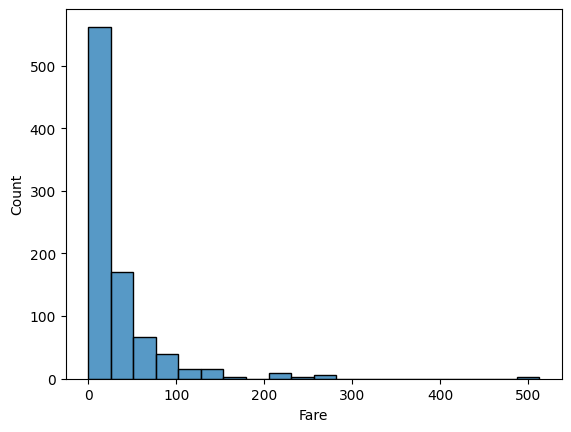

In [ ]:
# 단변량 2-6) Fare (운임 비용)

print(df_train["Fare"].describe())

# 수치형 연속형
sns.histplot(df_train["Fare"],bins=20)

# 분석
# 대부분의 승객이 50 달러 미만 20 ~ 30 달러 구간에 몰려있음

In [ ]:
# 3. 이변량 분석
# 변수 2개 사이의 관계를 분석하는 것

# 1. 수치확인
# 2. 시각화
# 3. 해석 순으로 진행

# 도메인 지식이 있는 경우 
# => 의미 있는 조합 선정 => 이변량 분석

# 의미 있는 조합을 먼저 고려
# 1. Sex ↔ Survived
# 2. Pclass ↔ Survived
# 3. Age ↔ Survived
# 4. Fare ↔ Survived
# 5. FamilySize ↔ Survived

# 도메인 지식이 없는 경우
# => 전체 변수 상관관계 확인 => 관계가 큰 변수 선택 => 이변량 분석 

# 기초통계량 => 단변량 분석 => 상관관계 분석 (Heatmap) => 이변량 분석 => 다변량 분석 (아예 모르겠으면 상관관계를 먼저 분석해서 진행)

# 실제 분석시에는 위의 두 조합을 전부 고려

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


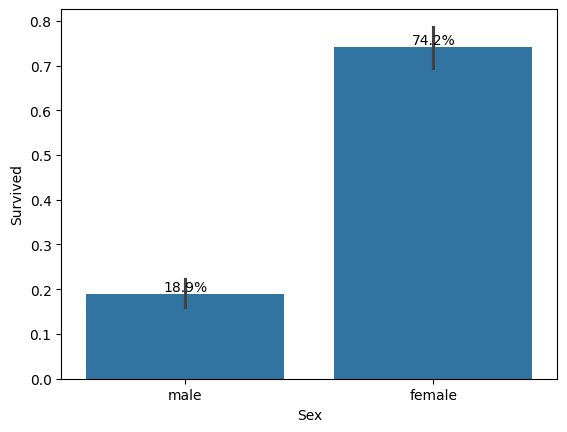

In [ ]:
# 1. Sex ↔ Survived
# 질문) 성별에 따른 생존률 차이가 있는가?

# result = pd.crosstab(df_train["Sex"],df_train["Survived"])
# print(result)

result = pd.crosstab(df_train["Sex"],df_train["Survived"],normalize="index") * 100
print(result)


ax = sns.barplot(
    x="Sex",
    y="Survived",
    data=df_train
)

for p in ax.patches:
    value = p.get_height()*100
    ax.annotate(
        f"{value:.1f}%",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

# 분석
# 여성 생존률 약 74%
# 남성 생존률 약 19%
# 성별 차이는 매우 큼
# 생존을 설명하는 강력한 변수 후보임


Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


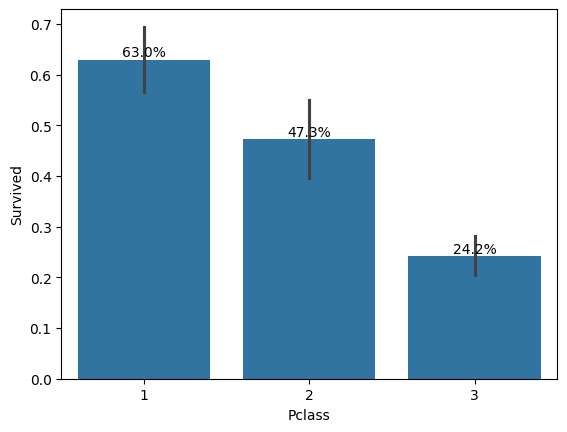

In [ ]:
# 2. Pclass ↔ Survived
# 질문) 객실 등급에 따른 생존률 차이가 있는가?

result = pd.crosstab(df_train["Pclass"],df_train["Survived"],normalize = "index") * 100
print(result)

ax = sns.barplot(
    x="Pclass",
    y="Survived",
    data=df_train
)

for p in ax.patches:

    percent = p.get_height()*100

    ax.annotate(
        f"{percent:.1f}%",
        (
            p.get_x()
            +
            p.get_width()/2,
            p.get_height()
        ),

        ha="center",
        va="bottom"
    )

    # 분석
    # 1등석 생존률 63%
    # 2등석 생존률 47%
    # 3등석 생존률 24%
    # 객실 등급이 낮아질수록 생존률 감소
    # 생존률을 설명하는 중요한 변수라고 여겨짐

          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         549.0  30.028233  12.499986  1.00  23.0  28.0  35.0  74.0
1         342.0  28.291433  13.764425  0.42  21.0  28.0  35.0  80.0


<Axes: xlabel='Survived', ylabel='Age'>

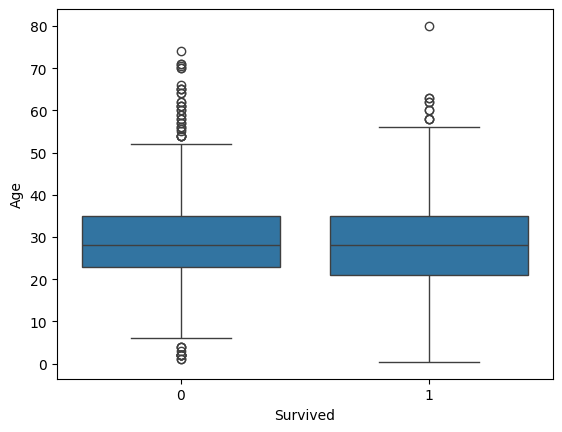

In [ ]:
# 3. Age ↔ Survived
# 질문) 나이에 따른 생존률 차이가 있는가?

result = df_train.groupby("Survived")["Age"].describe()
print(result)

# 사망 평균 나이 : 30.0
# 생존 평균 나이 : 23.3

sns.boxplot(x="Survived",y="Age",data=df_train)

# 분석
# 차이는 크지 않음
# 나이 단독 영향은 약함

          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


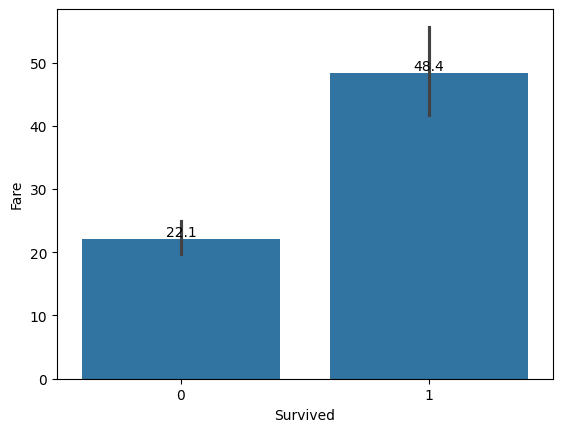

In [ ]:
# 4. Fare ↔ Survived
# 질문) 운임이 높을수록 생존률이 증가하는가?

result = df_train.groupby("Survived")["Fare"].describe()
print(result)

ax = sns.barplot(
    x="Survived",
    y="Fare",
    data=df_train
)

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1f}",
        (
            p.get_x() + p.get_width()/2,
            value
        ),
        ha="center",
        va="bottom"
    )

# 분석
# 사망 평균 요금 : 22
# 생존 평균 요금 : 48
# 운임 비용이 높은 승객의 생존률이 더 높음

FamilySize
1     30.4
2     55.3
3     57.8
4     72.4
5     20.0
6     13.6
7     33.3
8      0.0
11     0.0
Name: Survived, dtype: float64


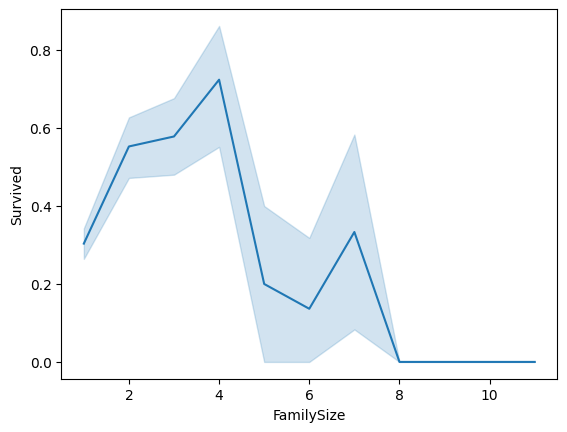

In [ ]:
# 5. FamilySize ↔ Survived
# 질문) 가족 구성원이 많을수록 생존률이 증가하는가?

result = (df_train.groupby("FamilySize")['Survived'].mean( )* 100)
print(result.round(1))

ax = sns.lineplot(x="FamilySize",y="Survived", data=df_train)
# 이런 그래프들은 그냥 수치로만 분석하는 게 더 좋을수도 있음

# 분석
# 혼자 탑승시 생존률이 낮음
# 2 ~ 4명 가족은 생존률이 50% 이상
# 가족이 많으면 생존률이 감소 (50% 미만)

In [ ]:
# 이변량 분석 결과

# | 조합                     | 결론          |
# | ---------------------   | --------      | 
# | Sex ↔ Survived          | 매우 강한 차이  |
# | Pclass ↔ Survived       | 강한 영향      |
# | Age ↔ Survived          | 영향 작음      |
# | Fare ↔ Survived         | 양의 관계      |
# | FamilySize ↔ Survived   | 비선형 관계    |

In [ ]:
# 4. 다변량 분석
# 3개 이상의 변수를 동시에 보고 패턴을 찾는 것

# 중요했던 변수들 위주로 조합

# 1. Sex + Pclass → Survived
# 2. Fare + Pclass → Survived
# 3. Age + FamilySize → Survived

Survived          0     1
Sex    Pclass            
female 1        3.2  96.8
       2        7.9  92.1
       3       50.0  50.0
male   1       63.1  36.9
       2       84.3  15.7
       3       86.5  13.5


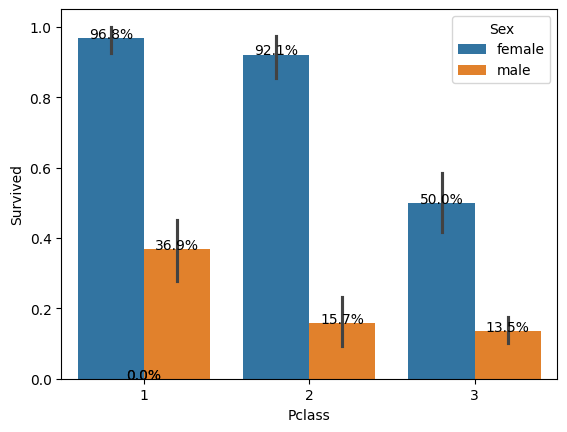

In [ ]:
# 4-1) Sex + Pclass → Survived

result = pd.crosstab([df_train["Sex"],df_train["Pclass"]],df_train["Survived"],normalize="index") * 100
print(result.round(1))

ax=sns.barplot(
x="Pclass",
y="Survived",
hue="Sex",
data=df_train
)

for p in ax.patches:
 value=p.get_height()*100
 ax.annotate(
 f"{value:.1f}%",
 (
 p.get_x()
 +
 p.get_width()/2,
 p.get_height()
 ),
 ha="center"
 )
 
# Survived

# 분석 
# 1등석 여성 생존률이 압도적
# 남성은 등급이 낮을수록 생존률 급감
# 성별 효과가 강력하게 나타남

Pclass  Survived
1       0           64.684007
        1           95.608029
2       0           19.412328
        1           22.055700
3       0           13.669364
        1           13.694887
Name: Fare, dtype: float64


<Axes: xlabel='Fare', ylabel='Pclass'>

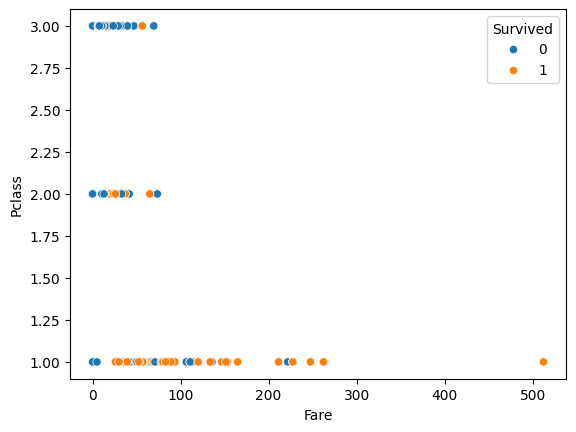

In [ ]:
# 4-2) Fare + Pclass → Survived

result = df_train.groupby(['Pclass','Survived'])["Fare"].mean()
print(result)

sns.scatterplot(
x="Fare",
y="Pclass",
hue="Survived",
data=df_train
)


# 분석
# 운임이 높을수록 생존률이 증가 하는 경향이 있음
# 이는 높은 운임을 지불한 승객이 주로 상위 객실(1등석)에 탑승했으며,상위 객실 승객이 구조 과정에서 상대적으로 유리했기 때문으로 해석 가능함

# Fare => survived 가 아니라 Fare => Pclass => Survived 임
# 운임 비용 자체 보다는 객실 등급이 생존을 설명하는 핵심 변수일 가능성이 있음

FamilySize  Survived
1           0           31.2
            1           31.0
2           0           31.6
            1           30.4
3           0           31.3
            1           22.5
4           0           24.1
            1           17.0
5           0           20.7
            1           31.0
6           0           17.6
            1           23.7
7           0           14.9
            1           15.8
8           0           15.7
11          0           28.0
Name: Age, dtype: float64


<Axes: xlabel='Age', ylabel='FamilySize'>

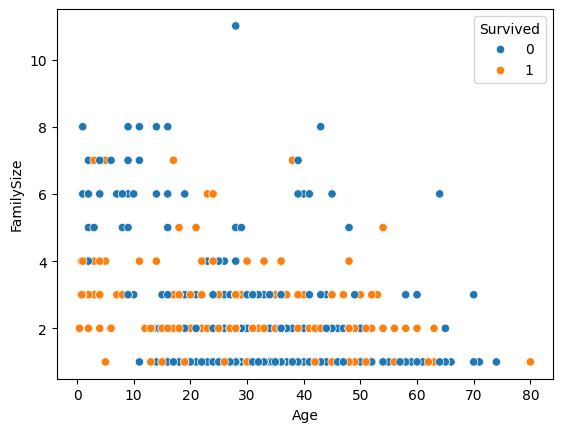

In [ ]:
# 4-3) Age + FamilySize → Survived
# 나이와 가족 규모를 보면 생존 차이가 있는가?

result = (df_train.groupby(['FamilySize','Survived']))["Age"].mean()
print(result.round(1))

sns.scatterplot(x="Age",y="FamilySize",hue="Survived",data=df_train)

# 분석
# 어린 승객 생존 높음
# 적당한 가족 규모가 유리
# 혼자 또는 너무 큰 가족은 생존률 감소

# 다변량 분석 최종 결론
# 성별 영향이 가장 큼
# 높은 객실 + 높은 운임 비용 유리
# 나이 영향은 상대적으로 약해 보이나 나이 대별로는 생존률 차이가 남
# 가족 규모는 적당할 때 생존률 증가

# 개인적 분석 희망
# Cabin 칼럼을 삭제하지 않고, 결측치 없음으로 채우고 분석
# 가족 규모는 적당할 때 생존률이 증가하였는데, 아이가 있는 가족을 우선 구조 되었을까? => 분석 희망
# 3. Age 결측치 처리시, Pclass 등급별 또는 중앙값으로 대체시 분석

In [ ]:
# 통계적 가설검정

# EDA
# ↓
# 가설 설정
# ↓
# 통계 검정
# ↓
# p-value 해석
# ↓
# 결론

In [ ]:
# 1. 객실 등급(Pclass)이 생존에 영향을 주는가?
# 객실 등급에 따라 생존률 차이가 정말 있는가?
# 아니면 우연인가?

# 귀무가설 : 객실 등급과 생존은 관계 없다.
# 대립가설 : 객실 등급과 생존은 관계 있다.

# 카이제곱 검정 (범주형 × 범주형)
# 사용 이유
# Pclass → 범주형
# Survived → 범주형

from scipy.stats import chi2_contingency

table = pd.crosstab(df_train["Pclass"],df_train["Survived"])
print(table)

st,pv,_,_ = chi2_contingency(table)

print("통계량 :",st)
print("p-value :",pv)

# 결론
# p < 0.05 보다 작음
# 객실 등급과 생존은 통계적으로 유의미한 관계가 있음

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
통계량 : 102.88898875696056
p-value : 4.549251711298793e-23


In [ ]:
# 생존자와 사망자의 평균 운임 비용은 차이가 있는가?
# 생존자 운임 비용이 높아 보이는데 진짜 차이가 있는가?

# 귀무가설 : 생존자와 사망자의 평균 운임 비용은 같다.
# 대립가설 : 평균 운임 비용이 다르다.

# 두 집단이 다르므로 독립표본 t 검정
# 두 집단이 아예 다른 표본이기에

from scipy.stats import ttest_ind

alive_Fare = df_train[df_train["Survived"]==1]["Fare"]
dead_Fare = df_train[df_train["Survived"]==0]["Fare"]

st,pv = ttest_ind(alive_Fare,dead_Fare)

print("t값 :",st)
print("p-value : ",pv)

# p-value < 0.05
# 평균 차이가 존재
# 생존자는 사망자보다 운임 비용이 높다고 볼 수 있음

t값 : 7.939191660871055
p-value :  6.120189341924198e-15
